# Analysing the raw data

Before we engineer any extra features for our data to use for in depth analysis, we can perform some surface level analysis and plot our data to gain an idea of how the simulation went, the shape of the data and ultimately, begin to provide an answer to how much luck you need to win on our target board.

### Setup

Let's import our data into two dataframes, one for the games and one for the decisions, so we can work with it, similarly to the end of the simulation notebook.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

games = pd.read_parquet("../data/raw/games")
decisions = pd.read_parquet("../data/raw/decisions")
skipped_games = pd.read_csv("../data/raw/skipped_boards.csv")

print(f"Number of games: {len(games)}")
print(f"Number of decisions: {len(decisions)}")
print(f"Number of games skipped: {len(skipped_games)}")
print(f"Skip rate: {100*(len(skipped_games))/50000:.2f}%")

Number of games: 49949
Number of decisions: 444589
Number of games skipped: 51
Skip rate: 0.10%


We can see that the pipeline collected data for the majority of the boards, with a low skip rate of 0.1%, so our data is a good sample of boards, not just ones that can be easily computed.

### Sanity Check

Before we proceed, let's check that all the data is valid and clean.

In [30]:
print(f"Missing values in games:\n{games.isna().sum()}")
print(f"Missing values in decisions:\n{decisions.isna().sum()}")

Missing values in games:
game_id                              0
num_cols                             0
num_rows                             0
mine_count                           0
remaining_mines                      0
num_guesses                          0
success_prob                         0
min_guess_prob                       0
max_guess_prob                       0
avg_guess_prob                       0
win_no_guess                         0
win                                  0
first_click                          0
cells_revealed_before_first_guess    0
dtype: int64
Missing values in decisions:
game_id                     0
guess_location              0
is_edge                     0
is_corner                   0
guess_number                0
guess_prob                  0
guess_result                0
component_size              0
num_valid_configs           0
mines_remaining_at_guess    0
dtype: int64


We can see that our data is complete, and so doesn't need cleaning. Let's check that the values make sense.

In [31]:
assert (games["success_prob"] >= 0).all() and (games["success_prob"] <= 1).all()
assert (games["num_guesses"] >= 0).all()
assert (decisions["guess_prob"] >= 0).all() and (decisions["guess_prob"] <= 1).all()

### First Answer

The first thing to do is to check how many games won, how many games won without guesses and calculate a win rate, to provide an initial answer to our question.

In [32]:
print(f"Number of games won: {games['win'].sum()}")
print(f"Win rate: {100*(games['win'].sum())/len(games):.3f}%")
print(f"Number of games won without guessing: {games['win_no_guess'].sum()}")
print(f"Win rate no guess: {100*(games['win_no_guess'].sum())/len(games):.3f}%")

Number of games won: 2
Win rate: 0.004%
Number of games won without guessing: 0
Win rate no guess: 0.000%


We have a near zero win rate, showing that it is very difficult to win at this level. Also, we can see that the two games that won only won through guessing. Let's take a closer look at the details of these games.

In [33]:
print(games[games["win"] == True])

      game_id  num_cols  num_rows  mine_count  remaining_mines  num_guesses  \
20535   20555        30        30         270                1           23   
31513   31546        30        30         270                1           38   

       success_prob  min_guess_prob  max_guess_prob  avg_guess_prob  \
20535      0.015930             0.0             0.5        0.150617   
31513      0.002849             0.0             0.5        0.132396   

       win_no_guess   win first_click  cells_revealed_before_first_guess  
20535         False  True    [20, 17]                                152  
31513         False  True      [8, 2]                                 26  


The main feature to focus on here is the success probability, where one had a 1.5% chance and the other had around a 0.3% to win the board in the first place. From this alone we can't conclude that these were just simply better boards; It is more likely that the simulator happened to get very lucky on these runs.

Looking at the amount of cells revealed before the first guess, we can see that board 20555 may have been better, as it revealed more than half the board before making a guess, which also lead to it taking less guesses (23) compared to game 31546. Let's take a look at the actual decisions made in the two games.

In [34]:
print(decisions[decisions["game_id"] == "20555"])

       game_id guess_location  is_edge  is_corner  guess_number  guess_prob  \
183867   20555        [15, 8]    False      False             1    0.045484   
183868   20555        [16, 8]    False      False             2    0.025078   
183869   20555       [15, 11]    False      False             3    0.074191   
183870   20555       [15, 10]    False      False             4    0.032963   
183871   20555        [13, 6]    False      False             5    0.000000   
183872   20555        [2, 21]    False      False             6    0.000000   
183873   20555        [1, 29]     True      False             7    0.066107   
183874   20555        [0, 17]     True      False             8    0.064670   
183875   20555        [8, 28]    False      False             9    0.114681   
183876   20555        [8, 29]     True      False            10    0.112972   
183877   20555       [13, 21]    False      False            11    0.118602   
183878   20555        [9, 29]     True      False   

In game 20555, we made only 2 50 50 guesses, which leads us to believe that a large amount of the board was pretty safe. We can also see that between 215 and 85 mines remaining, no guesses were made, which shows that a big portion of the board was solved purely through deduction.

In [35]:
print(decisions[decisions["game_id"] == "31546"])

       game_id guess_location  is_edge  is_corner  guess_number  guess_prob  \
281738   31546         [5, 5]    False      False             1    0.000000   
281739   31546        [10, 6]    False      False             2    0.000000   
281740   31546        [12, 0]     True      False             3    0.000000   
281741   31546        [9, 10]    False      False             4    0.000000   
281742   31546        [27, 6]    False      False             5    0.000000   
281743   31546        [24, 1]    False      False             6    0.174390   
281744   31546        [19, 0]     True      False             7    0.080009   
281745   31546        [25, 3]    False      False             8    0.174267   
281746   31546       [16, 12]    False      False             9    0.210986   
281747   31546       [10, 11]    False      False            10    0.224184   
281748   31546        [9, 14]    False      False            11    0.000000   
281749   31546        [7, 25]    False      False   

Similarly, game 31546 also finished on 2 50 50s. In actual fact, the number of guesses is a false indicator of the game being less safe, as we can see that a lot of the guesses had a zero probability of being a mine to 6 decimal places, so they were almost guaranteed safe just calculated through enumeration.

### Visualising the Data

Let's plot the data as a whole to gain further insight into our sample, and gain context for the performance of our solver on the winning boards.

We can plot the first click distribution as a heatmap, to confirm that they were selected randomly.

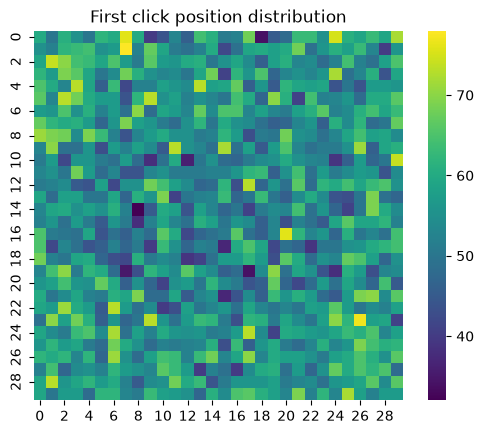

In [36]:
# Unpack the tuples into separate row/col columns
games["first_click_row"] = games["first_click"].apply(lambda rc: rc[0])
games["first_click_col"] = games["first_click"].apply(lambda rc: rc[1])

# Build a grid counting how many games clicked each cell
board_rows, board_cols = 30, 30
grid = np.zeros((board_rows, board_cols))

for r, c in zip(games["first_click_row"], games["first_click_col"]):
    grid[r, c] += 1

# Plot the grid as a heatmap
sns.heatmap(grid, cmap="viridis", square=True)
plt.title("First click position distribution")
plt.show()

Although the heatmap doesn't apper to be particularly flat, we cannot see any signs of a pattern or bias, which implies that the uniform randomisation worked.

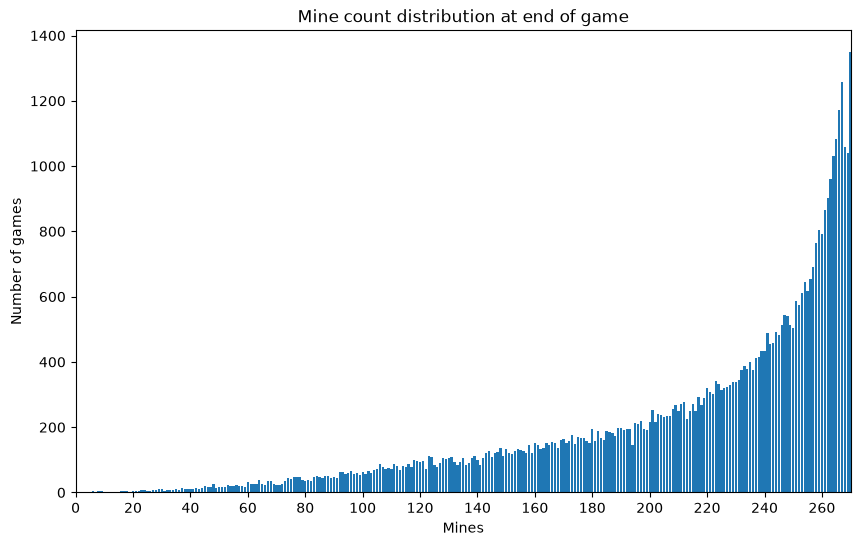

In [43]:
from matplotlib.ticker import MultipleLocator

remaining_mine_counts = games["remaining_mines"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(remaining_mine_counts.index, remaining_mine_counts.values, color="tab:blue")

ax.xaxis.set_major_locator(MultipleLocator(20))
ax.set_xlim(0,270)
ax.set_xlabel("Mines")
ax.set_ylabel("Number of games")
ax.set_title("Mine count distribution at end of game")
plt.show()

We can see that the remaining mines at the end of each game follow an exponential distribution, which is to be expected since most games will lose nearer the start than towards the end. Let's see how many games got below the 20 mine count mark.

In [46]:
print(games[games["remaining_mines"] <= 20].sort_values(by="remaining_mines"))

      game_id  num_cols  num_rows  mine_count  remaining_mines  num_guesses  \
20535   20555        30        30         270                1           23   
31513   31546        30        30         270                1           38   
36955   36993        30        30         270                2           48   
4881     4886        30        30         270                2           36   
49611   49663        30        30         270                3           46   
35465   35494        30        30         270                3           49   
1005     1007        30        30         270                3           36   
29967   30005        30        30         270                4           26   
35654   35695        30        30         270                4           50   
1151     1150        30        30         270                6           36   
34345   34381        30        30         270                6           25   
48174   48218        30        30         270       

We can see that a lot of games got to a final decision with a few mines remaining and lost on one of the last guesses, which shows that the wins aren't an anomaly and are to be expected when so many games are reaching the final stages of the board.

## Adding Context to Our Wins


We now have a broad view of the shape of the data. Before moving on to feature engineering, let's look at the distributions of the key features. We can mark our winning games in red on each plot where appropriate to see how the winning games compare to the general distribution of the whole sample.

### Game distributions


Let's start with distributions which are calculated for the whole game.


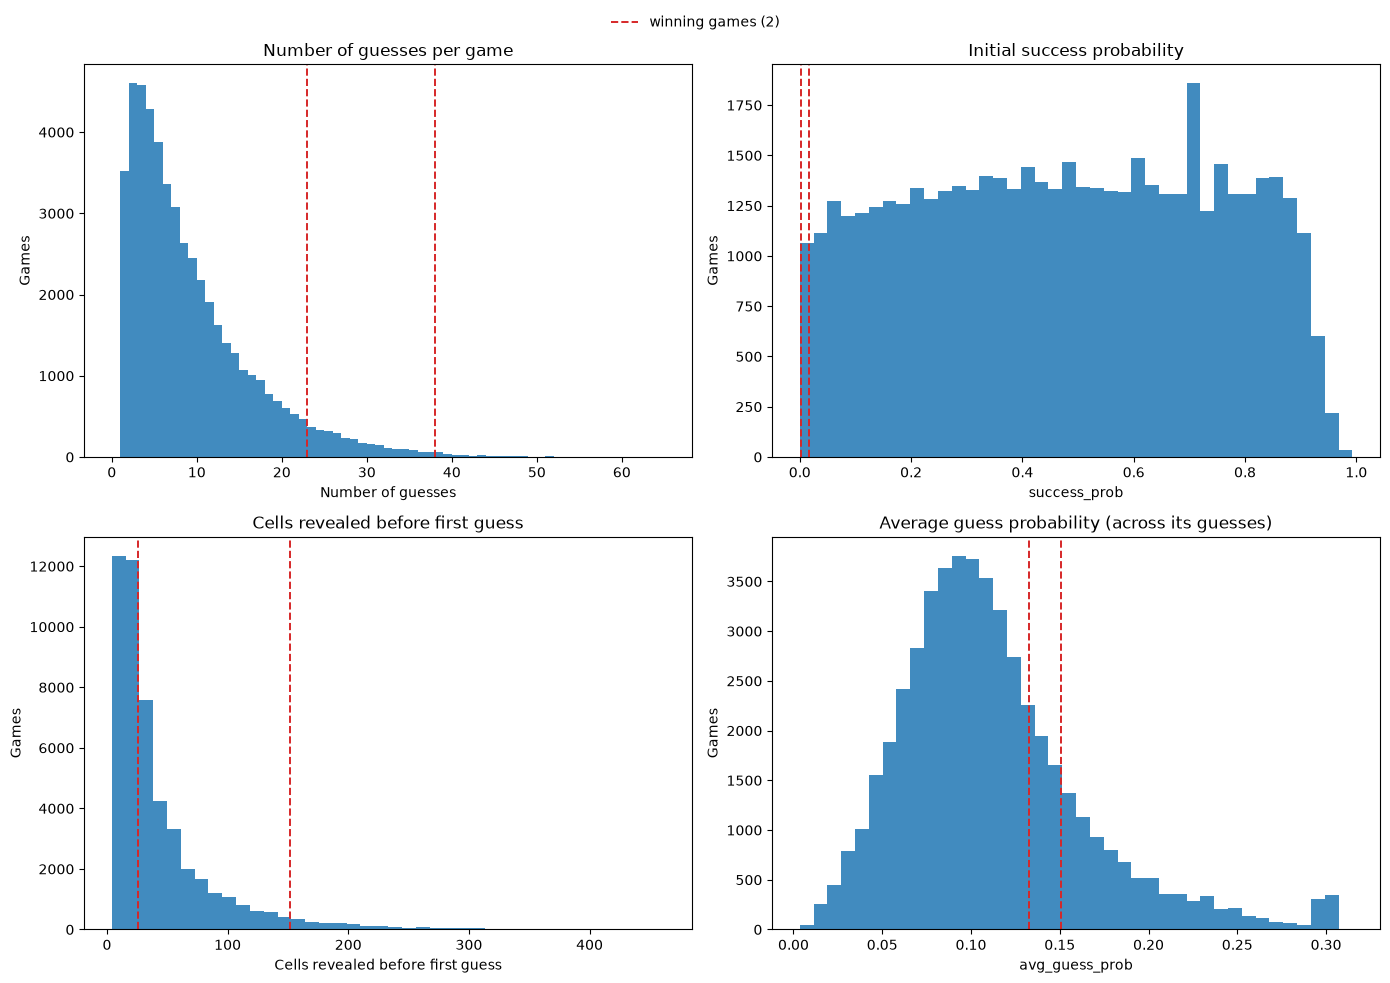

In [38]:
win_games = games[games["win"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of guesses
ax = axes[0, 0]
ax.hist(games["num_guesses"], bins=np.arange(0, games["num_guesses"].max() + 2),
        color="tab:blue", alpha=0.85)
for v in win_games["num_guesses"]:
    ax.axvline(v, color="tab:red", ls="--", lw=1.4)
ax.set_xlabel("Number of guesses")
ax.set_ylabel("Games")
ax.set_title("Number of guesses per game")

# Success probability
ax = axes[0, 1]
ax.hist(games["success_prob"], bins=40, color="tab:blue", alpha=0.85)
for v in win_games["success_prob"]:
    ax.axvline(v, color="tab:red", ls="--", lw=1.4)
ax.set_xlabel("success_prob")
ax.set_ylabel("Games")
ax.set_title("Initial success probability")

# Cells revealed before first guess
ax = axes[1, 0]
ax.hist(games["cells_revealed_before_first_guess"], bins=40, color="tab:blue", alpha=0.85)
for v in win_games["cells_revealed_before_first_guess"]:
    ax.axvline(v, color="tab:red", ls="--", lw=1.4)
ax.set_xlabel("Cells revealed before first guess")
ax.set_ylabel("Games")
ax.set_title("Cells revealed before first guess")

# Average guess probability
ax = axes[1, 1]
ax.hist(games["avg_guess_prob"], bins=40, color="tab:blue", alpha=0.85)
for v in win_games["avg_guess_prob"]:
    ax.axvline(v, color="tab:red", ls="--", lw=1.4)
ax.set_xlabel("avg_guess_prob")
ax.set_ylabel("Games")
ax.set_title("Average guess probability (across its guesses)")

fig.legend([plt.Line2D([0], [0], color="tab:red", ls="--", lw=1.4)],
           ["winning games (2)"], loc="upper center", ncol=1, frameon=False,
           bbox_to_anchor=(0.5, 0.985))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


A few things stand out:

- On **number of guesses**, the wins (23 and 38) sit squarely in the middle of the pack, many losing games used far fewer guesses. This means a low guess count is not what separates wins from losses.
- On **success probability**, both wins are in the far left tail (0.3% and 1.6%). This is to be expected since they got way further through the game, so they had to make more guesses. The distribution is otherwise flat, which shows that our solver didn't get overly lucky in general.
- On **cells revealed before the first guess**, the two wins are at opposite ends of the spectrum: one revealed 152 cells before ever guessing, the other only 26. We can see that revealing many cells by deduction initially doesn't necessarily mean anything. This could imply that there isn't a direct relationship between amount of deduction at the start and progression through the board, however this will be checked later on.
- On **average guess probability**, both wins are around the median, which is expected since we always pick the lowest probability guess at each stage.

All of this points the same way: these boards were won by **luck during play**, not by being dealt favourable boards. Let's confirm that at the decision level.


### Decision distributions


Now the per-guess `decisions` table, which contains every individual guess across all boards. Let's compare guesses in the winning games to all other guesses.


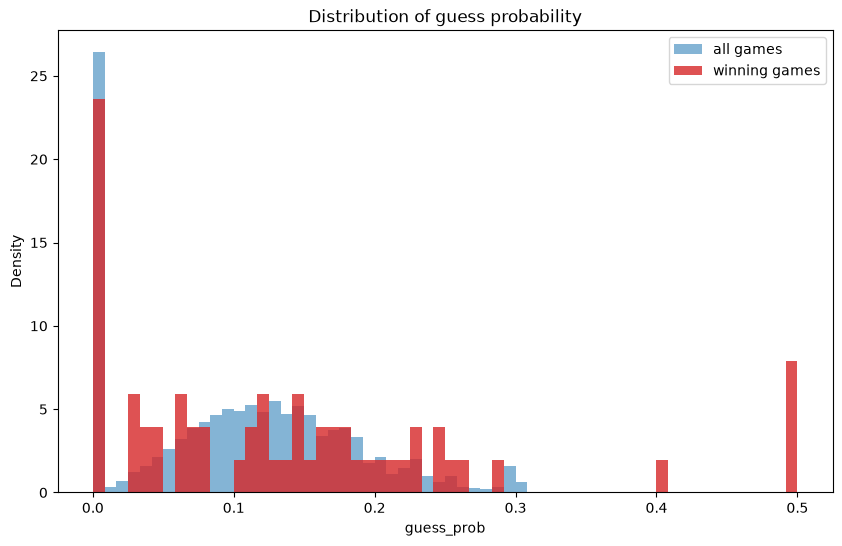

all games:     mean guess_prob = 0.1046
winning games: mean guess_prob = 0.1393


In [39]:
win_decisions = decisions[decisions["game_id"].isin(win_games["game_id"])]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(decisions["guess_prob"], bins=60, color="tab:blue", alpha=0.55,
        label="all games", density=True)
ax.hist(win_decisions["guess_prob"], bins=60, color="tab:red", alpha=0.8,
        label="winning games", density=True)
ax.set_xlabel("guess_prob")
ax.set_ylabel("Density")
ax.set_title("Distribution of guess probability")
ax.legend()
plt.show()

print(f"all games:     mean guess_prob = {decisions['guess_prob'].mean():.4f}")
print(f"winning games: mean guess_prob = {win_decisions['guess_prob'].mean():.4f}")


Most guesses carry a small risk (the distribution is heavy near 0.05–0.2). The winning games' guesses are spread across roughly the same range, sitting slightly to the riskier side on average. However, this is not only an indication of the amount of luck in those games, but also shows that to win a game, you have to eventually encounter risky guesses,as we already discussed. 

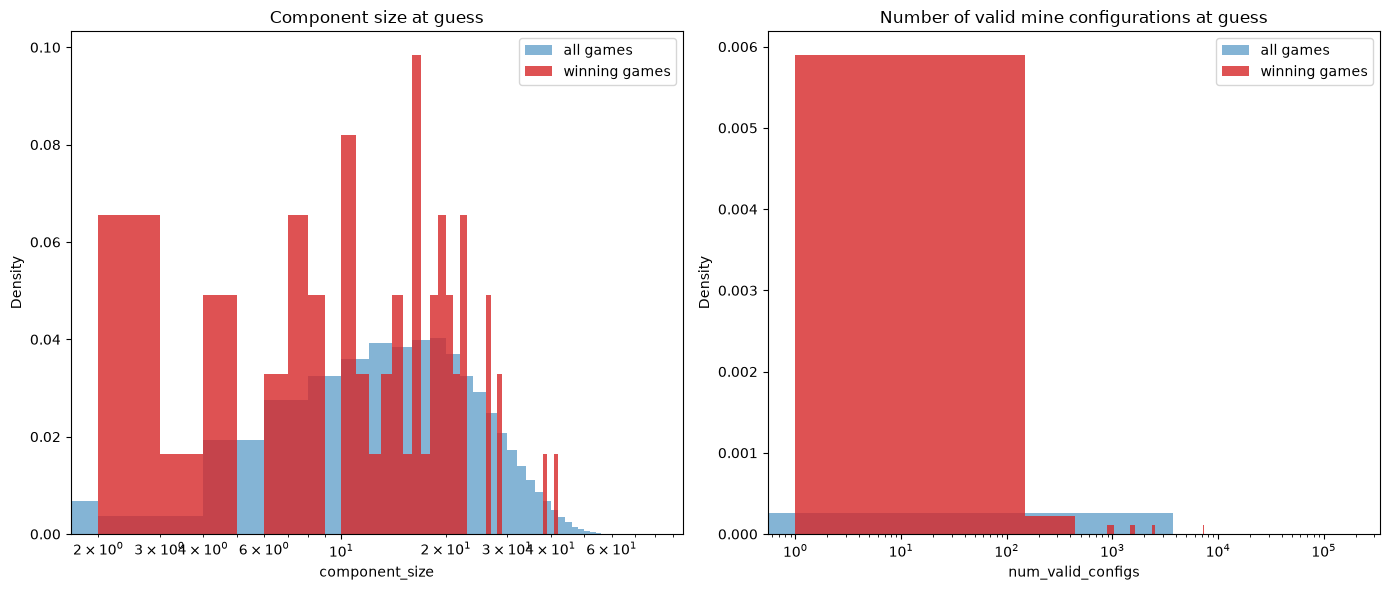

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Component size (log x, since it is right-skewed)
ax = axes[0]
ax.hist(decisions["component_size"], bins=40, color="tab:blue", alpha=0.55,
        label="all games", density=True)
ax.hist(win_decisions["component_size"], bins=40, color="tab:red", alpha=0.8,
        label="winning games", density=True)
ax.set_xscale("log")
ax.set_xlabel("component_size")
ax.set_ylabel("Density")
ax.set_title("Component size at guess")
ax.legend()

# Number of valid configs (log x)
ax = axes[1]
ax.hist(decisions["num_valid_configs"], bins=50, color="tab:blue", alpha=0.55,
        label="all games", density=True)
ax.hist(win_decisions["num_valid_configs"], bins=50, color="tab:red", alpha=0.8,
        label="winning games", density=True)
ax.set_xscale("log")
ax.set_xlabel("num_valid_configs")
ax.set_ylabel("Density")
ax.set_title("Number of valid mine configurations at guess")
ax.legend()

plt.tight_layout()
plt.show()


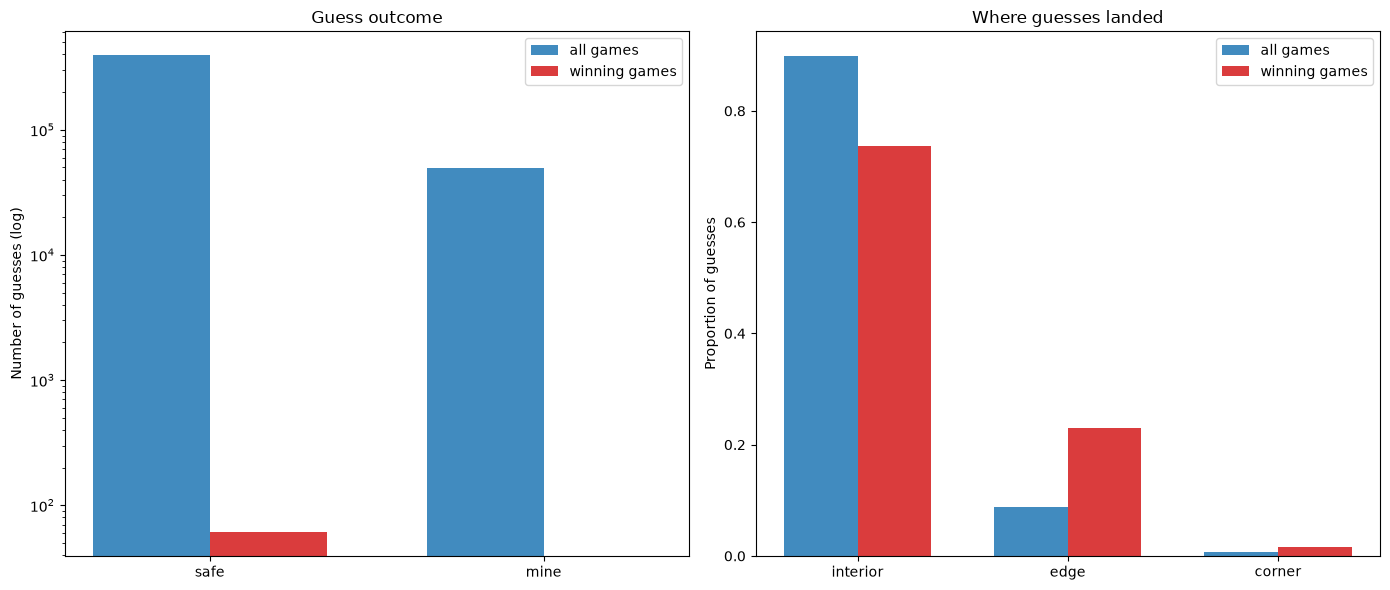

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Guess outcome
ax = axes[0]
order = ["safe", "mine"]
all_counts = decisions["guess_result"].value_counts().reindex(order).fillna(0)
win_counts = win_decisions["guess_result"].value_counts().reindex(order).fillna(0)
x = np.arange(len(order))
w = 0.35
ax.bar(x - w / 2, all_counts.values, w, color="tab:blue", alpha=0.85, label="all games")
ax.bar(x + w / 2, win_counts.values, w, color="tab:red", alpha=0.9, label="winning games")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Number of guesses (log)")
ax.set_title("Guess outcome")
ax.legend()

# Where the guesses landed (position on board)
ax = axes[1]
pos_all = np.array([1 - decisions["is_edge"].mean() - decisions["is_corner"].mean(),
                    decisions["is_edge"].mean() - decisions["is_corner"].mean() * 0,
                    decisions["is_corner"].mean()])
pos_all[1] = decisions["is_edge"].mean() - decisions["is_corner"].mean()  # edges only (not corners)
pos_win = np.array([1 - win_decisions["is_edge"].mean() - win_decisions["is_corner"].mean(),
                    win_decisions["is_edge"].mean() - win_decisions["is_corner"].mean(),
                    win_decisions["is_corner"].mean()])
labels = ["interior", "edge", "corner"]
ax.bar(np.arange(3) - w / 2, pos_all, w, color="tab:blue", alpha=0.85, label="all games")
ax.bar(np.arange(3) + w / 2, pos_win, w, color="tab:red", alpha=0.9, label="winning games")
ax.set_xticks(np.arange(3))
ax.set_xticklabels(labels)
ax.set_ylabel("Proportion of guesses")
ax.set_title("Where guesses landed")
ax.legend()

plt.tight_layout()
plt.show()


We can see that in the winning games, more guesses were placed on the edge of the board. This can be explained by the smaller amount of constraints when by the edge, meaning that maybe guesses in this region were more likely to pay off.


### Summary

Taken together, the distributions give a consistent picture of the 2 wins out of ~50,000 games:

1. They were **not** easy boards, both sit in the lowest tail of success probability.
2. They used an **ordinary** number of guesses with **ordinary** risk levels.
3. Their guesses were made on **normal sized** frontier components.
4. The distinguishing factor is simply that **every guess happened to be safe**, including unusually many edge guesses.

The wins therefore represent extreme runs of luck within the solver's decision making, not evidence that some boards are solvable with less luck than others. That said, to answer the leading question rigorously we need to move from these aggregate plots to engineered, per-guess features (e.g. how large a safe expansion followed a guess, or how the success probability evolved), which we'll do in the next notebook before fitting a model.
